# 线性回归（Linear Regression）

基于梯度下降的线性回归实现（单特征 / 多特征通用）。

**约定说明**
- 模型：`F(X) = X·θ`
- 偏置 b 已并入 `θ` 的第一个元素 `theta[0]`，对应 `X` 第一列的全 1
- 特征先做标准化（每个特征分别减均值、除以标准差）

**数据集**
- data1：`ex1data1.txt`（单特征）
- data2：`ex1data2.txt`（多特征）
- 切换方式：修改「读取数据」cell 中的 `DATA_FILE`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# 配置 matplotlib 支持中文显示（避免 CJK 字形缺失警告）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False   # 修复负号显示为方块的问题

## 1. 读取数据

数据文件需与本 notebook 同目录。**每一项列的含义**：

| 数据集 | 文件 | 各列含义 |
| --- | --- | --- |
| data1 | ex1data1.txt | 第0列：人口 population；第1列：利润 profit（目标）|
| data2 | ex1data2.txt | 第0列：房屋面积 area；第1列：卧室数 bedrooms；第2列：房价 price（目标）|

切换数据集：只需修改下一 cell 的 `DATA_FILE`。

In [2]:
# ===== 数据集说明 =====
# data1 = ex1data1.txt（单特征，2 列）
#   第0列：人口 population
#   第1列：利润 profit（目标）
# data2 = ex1data2.txt（多特征，3 列）
#   第0列：房屋面积 area
#   第1列：卧室数 bedrooms
#   第2列：房价 price（目标）
# =====================
DATA_FILE = 'ex1data2.txt'   # 改为 'ex1data2.txt' 即切换为多特征数据

df_data = pd.read_csv(DATA_FILE, header=None)

print("===== 查看数据前五行 =====")
print(df_data.head())

print("\n===== 查看数据信息 =====")
print(df_data.info())

print("\n===== 查看数据统计信息 =====")
print(df_data.describe())

===== 查看数据前五行 =====
      0  1       2
0  2104  3  399900
1  1600  3  329900
2  2400  3  369000
3  1416  2  232000
4  3000  4  539900

===== 查看数据信息 =====
<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       47 non-null     int64
 1   1       47 non-null     int64
 2   2       47 non-null     int64
dtypes: int64(3)
memory usage: 1.2 KB
None

===== 查看数据统计信息 =====
                 0          1              2
count    47.000000  47.000000      47.000000
mean   2000.680851   3.170213  340412.659574
std     794.702354   0.760982  125039.899586
min     852.000000   1.000000  169900.000000
25%    1432.000000   3.000000  249900.000000
50%    1888.000000   3.000000  299900.000000
75%    2269.000000   4.000000  384450.000000
max    4478.000000   5.000000  699900.000000


## 2. 原始数据分布

单特征：特征 vs 目标；多特征：第 0 个特征 vs 目标（y 轴始终取最后一列）。

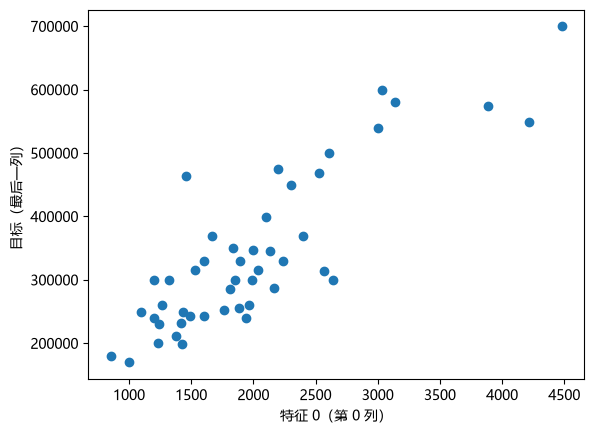

In [3]:
plt.scatter(df_data.iloc[:, 0], df_data.iloc[:, -1], marker='o')
plt.xlabel('特征 0（第 0 列）')
plt.ylabel('目标（最后一列）')
plt.show()

## 3. 特征缩放与数据准备

- `get_X`：取除最后一列外的所有特征列（兼容多特征），按列标准化后追加全 1 偏置列
- `get_y`：取最后一列作为目标

In [4]:
def get_X(df_data):
    # 提取特征列：除最后一列外的所有列（最后一列为目标 y）
    X = df_data.iloc[:, :-1].values
    # 特征缩放：每个特征分别减去均值、除以标准差（按列 axis=0）
    X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    # 添加偏置项（全 1 列），对应 theta[0]——即原来的偏置 b
    X = np.column_stack((np.ones(len(X)), X))
    return X


def get_y(df_data):
    # 提取目标列（最后一列）
    y = df_data.iloc[:, -1].values
    return y

## 4. 模型定义

- 代价函数：`J(θ) = (1/2m) · Σ(F(xᵢ) − yᵢ)²`
- 梯度下降更新：`θ = θ − α · ∂J(θ)/∂θ`
- 梯度（向量化）：`∂J(θ)/∂θ = (1/m) · Xᵀ·(X·θ − y)`

In [5]:
def cost_function(X, y, theta):
    # 计算样本数量
    m = len(y)
    # 计算预测值
    predictions = X.dot(theta)
    # 计算代价
    cost = (1 / (2 * m)) * np.sum(np.square(predictions - y))
    return cost


def gradient_descent(X, y, theta, alpha):
    # 计算样本数量
    m = len(y)
    # 计算预测值
    predictions = X.dot(theta)
    # 计算代价函数的导数（向量化：一次算出所有特征含偏置的梯度）
    d_theta = (1 / m) * X.T.dot(predictions - y)
    # 更新参数
    theta = theta - alpha * d_theta
    return theta


def batch_gradient_descent(X, y, theta, alpha=0.01, epoch=1000):
    # 迭代更新参数，并记录每次迭代的代价
    cost_data = [cost_function(X, y, theta)]
    _theta = np.copy(theta)
    for i in range(epoch):
        _theta = gradient_descent(X, y, _theta, alpha)
        cost_data.append(cost_function(X, y, _theta))
    return _theta, cost_data

## 5. 训练

初始化参数 → 反复「算代价 → 算梯度 → 更新参数」迭代 N 次 → 用代价曲线确认收敛。

In [6]:
# 1. 准备数据
X = get_X(df_data)
y = get_y(df_data)

# 2. 初始化参数与超参
theta = np.zeros(X.shape[1])   # X 已含偏置列，θ 为 n+1 维向量（theta[0] 即偏置 b）
alpha = 0.01                   # 学习率
epoch = 1500                   # 迭代次数

# 3. 运行训练
theta, cost_data = batch_gradient_descent(X, y, theta, alpha, epoch)

print('训练完成')
print(f'theta = {theta}')           # theta[0] 是偏置 b
print(f'初始代价 J(θ) = {cost_data[0]:.6f}')
print(f'最终代价 J(θ) = {cost_data[-1]:.6f}')

训练完成
theta = [340412.56301439 109370.05670466  -6500.61509507]
初始代价 J(θ) = 65591548106.457443
最终代价 J(θ) = 2043282709.932755


## 6. 可视化验证

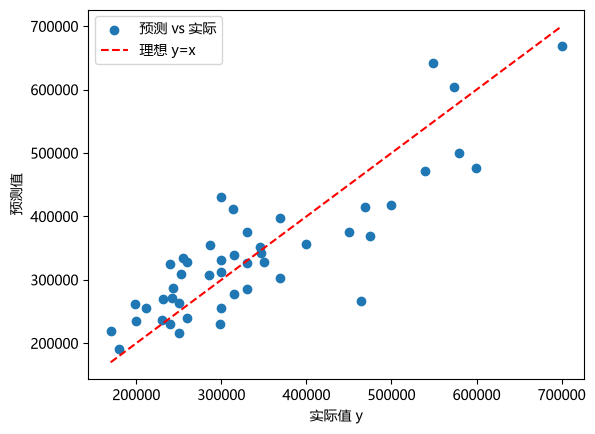

In [7]:
# 图 A：拟合效果
# 单特征：原始数据散点 + 拟合直线
# 多特征：预测值 vs 实际值（越贴近 y=x 对角线说明拟合越好）
if X.shape[1] == 2:
    plt.scatter(df_data.iloc[:, 0], y, marker='o', label='原始数据')
    plt.plot(df_data.iloc[:, 0], X.dot(theta), color='red', label='拟合直线')
    plt.xlabel('特征 0（第 0 列）')
    plt.ylabel('目标（最后一列）')
    plt.legend()
else:
    plt.scatter(y, X.dot(theta), label='预测 vs 实际')
    lo, hi = float(y.min()), float(y.max())
    plt.plot([lo, hi], [lo, hi], color='red', ls='--', label='理想 y=x')
    plt.xlabel('实际值 y')
    plt.ylabel('预测值')
    plt.legend()
plt.show()

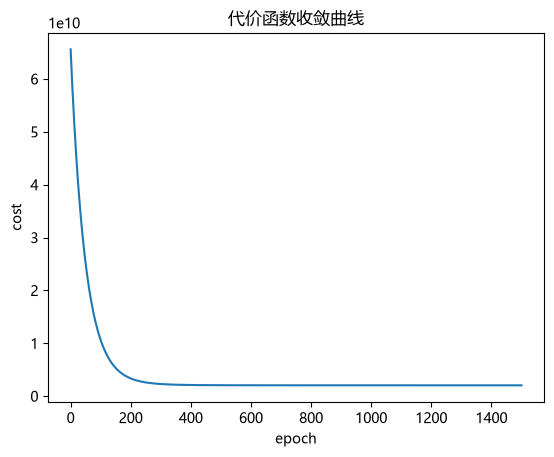

In [8]:
# 图 B：代价收敛曲线（应单调下降并趋于水平）
plt.plot(cost_data)
plt.xlabel('epoch')
plt.ylabel('cost')
plt.title('代价函数收敛曲线')
plt.show()

## 7.（可选）学习率对比

用不同学习率各训练一次，对比收敛速度。学习率过大会导致代价曲线震荡或上升。

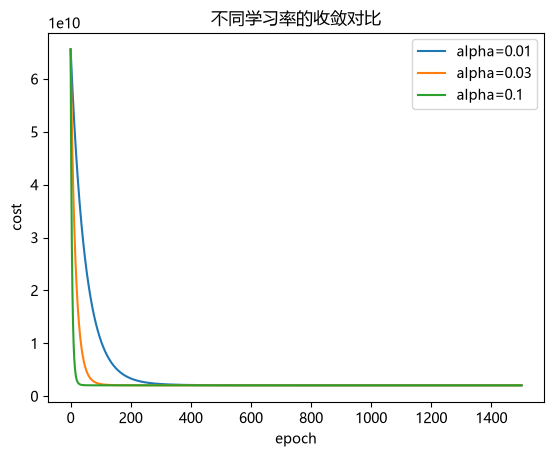

In [9]:
for a in [0.01, 0.03, 0.1]:
    _, c = batch_gradient_descent(X, y, np.zeros(X.shape[1]), alpha=a, epoch=1500)
    plt.plot(c, label=f'alpha={a}')
plt.xlabel('epoch')
plt.ylabel('cost')
plt.legend()
plt.title('不同学习率的收敛对比')
plt.show()

## 8.（可选）预测

新样本需要与训练时使用相同的特征缩放（按列 axis=0）。

- data1 示例：`new_x = np.array([8.0])`（人口 8 万）
- data2 示例：`new_x = np.array([2104, 3])`（面积 2104、卧室 3）

> 新样本个数必须与特征数一致，代码会自动按数据集的特征数切换。

In [10]:
# 预测：新样本需使用与训练时相同的特征缩放（按列）
if DATA_FILE == 'ex1data1.txt':
    new_x = np.array([8.0])         # data1：人口 8 万
else:
    new_x = np.array([2104, 3])     # data2：面积 2104、卧室 3

X_raw = df_data.iloc[:, :-1].values
mu = np.mean(X_raw, axis=0)         # 按列均值
sigma = np.std(X_raw, axis=0)       # 按列标准差
new_x_scaled = (new_x - mu) / sigma
new_X = np.concatenate(([1], new_x_scaled))  # 拼接偏置列
pred = new_X.dot(theta)
print(f'预测结果: {pred:.4f}')

预测结果: 356255.2211
